In [ ]:
# --- MNIST Digit Classification: Deep Learning ---
# Imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import Callback
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    accuracy_score,
)
import pandas as pd

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


# MNIST Digit Classification with Deep Learning

**Objective:** Train a feedforward neural network to classify handwritten digits (0–9) from the MNIST dataset. This notebook includes:
- **Training & validation curves** (loss and accuracy over epochs)
- **Cost decrease with backpropagation** (loss per batch within selected epochs)
- **Evaluation metrics:** accuracy, precision, recall, F1-score (per class and macro/weighted), confusion matrix
- **Summary tables** for reporting

**Workflow:** We load and preprocess MNIST, define a small MLP, train with validation monitoring, then plot epoch-level and batch-level loss to show convergence and the effect of backpropagation. Finally we evaluate on the test set and report accuracy, precision, recall, F1, and a confusion matrix. Each section ends with an explanation for what the numbers and plots mean.

---
## 1. Data loading and preprocessing

In [3]:
# Load MNIST data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values (0-255 → 0-1) for stable gradients in backpropagation
x_train = x_train.astype(np.float32) / 255.0
x_test = x_test.astype(np.float32) / 255.0

# One-hot encode the labels for categorical cross-entropy loss
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# Data summary
print("Dataset shapes:")
print(f"  x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"  x_test:  {x_test.shape},  y_test:  {y_test.shape}")
print(f"  Pixel range: [{x_train.min():.2f}, {x_train.max():.2f}]")
print(f"  Classes: {np.unique(y_train)}")


Dataset shapes:
  x_train: (60000, 28, 28), y_train: (60000,)
  x_test:  (10000, 28, 28),  y_test:  (10000,)
  Pixel range: [0.00, 1.00]
  Classes: [0 1 2 3 4 5 6 7 8 9]


**Interpretation:** We use 60,000 training and 10,000 test images of shape 28×28. Normalizing to [0, 1] keeps gradients stable during backpropagation. One-hot encoding turns each integer label (0–9) into a 10-dimensional vector so the model can use categorical cross-entropy. The class distribution in MNIST is roughly balanced, which avoids the need for class weighting.

---
## 2. Model architecture and training setup

In [4]:
# Feedforward MLP: Flatten → Dense(128) → Dense(64) → Dense(10, softmax)
model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax"),
])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

**Architecture & training:** The MLP (multi-layer perceptron) has ~109K parameters (784→128→64→10). ReLU in hidden layers avoids vanishing gradients; softmax on the output gives class probabilities. Adam optimiser adapts the learning rate per parameter, which helps loss decrease quickly. Categorical cross-entropy is the standard loss for multi-class classification; it measures how far the predicted distribution is from the true one-hot label.

In [5]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)


In [6]:
# Callback to record loss per batch (to visualize cost decrease with backpropagation)
# We record batches for the first 2 epochs only to keep the plot readable.
batch_losses = []  # list of (epoch, batch_idx, loss) for selected epochs
epochs_to_record_batches = {0, 1}  # first two epochs

class BatchLossLogger(Callback):
    def on_batch_end(self, batch, logs=None):
        if logs and "loss" in logs and self.model is not None:
            epoch = getattr(self, "_current_epoch", 0)
            if epoch in epochs_to_record_batches:
                batch_losses.append((epoch, batch, float(logs["loss"])))
    def on_epoch_begin(self, epoch, logs=None):
        self._current_epoch = epoch

batch_callback = BatchLossLogger()

# Training
EPOCHS = 10
BATCH_SIZE = 32
VAL_SPLIT = 0.1

history = model.fit(
    x_train, y_train_cat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    callbacks=[batch_callback],
    verbose=1,
)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9249 - loss: 0.2544 - val_accuracy: 0.9655 - val_loss: 0.1102
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9675 - loss: 0.1071 - val_accuracy: 0.9697 - val_loss: 0.0941
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9774 - loss: 0.0742 - val_accuracy: 0.9733 - val_loss: 0.0884
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9839 - loss: 0.0534 - val_accuracy: 0.9727 - val_loss: 0.0909
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9867 - loss: 0.0421 - val_accuracy: 0.9747 - val_loss: 0.1007
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9894 - loss: 0.0347 - val_accuracy: 0.9748 - val_loss: 0.1010
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9904 - loss: 0.0287 - val_accuracy: 0.9707 - val_loss: 0.1244
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9914 - loss: 0.0262 - 

**Epoch-level curves:** Training loss should fall and training accuracy rise as the model fits the data. Validation curves show generalization: if validation loss stops improving or starts rising while training loss keeps falling, that suggests overfitting. Here, train and validation accuracy both reach the high 90s and validation loss stays in a similar range to the final epochs, so the model is learning without severe overfitting. The gap between train and validation loss by the end is normal for a model that fits the training set well.

---
## 3. Training and validation curves

Loss and accuracy over epochs show convergence. **Training loss** decreases as the model fits the data via backpropagation; **validation loss** indicates generalization.

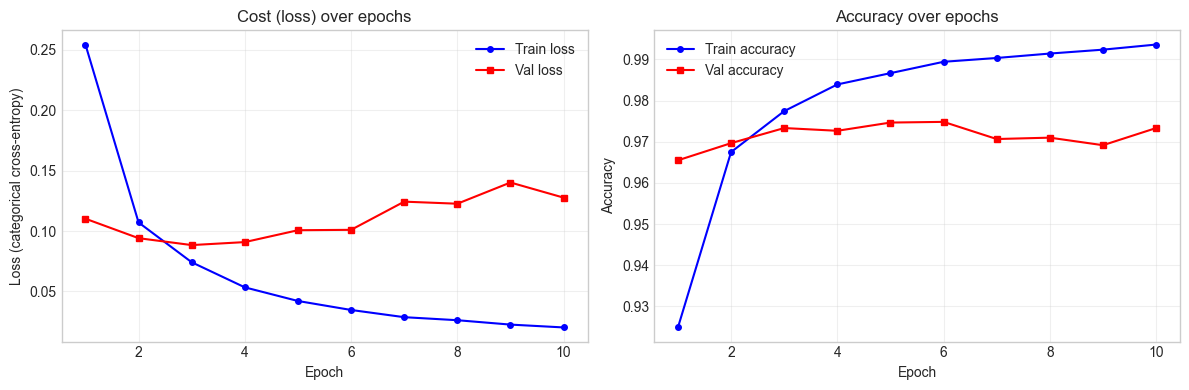

In [8]:
# Training & validation: Loss and accuracy vs epoch
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, len(history.history["loss"]) + 1)

# Loss curve
axes[0].plot(epochs_range, history.history["loss"], "b-o", label="Train loss", markersize=4)
axes[0].plot(epochs_range, history.history["val_loss"], "r-s", label="Val loss", markersize=4)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (categorical cross-entropy)")
axes[0].set_title("Cost (loss) over epochs")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(epochs_range, history.history["accuracy"], "b-o", label="Train accuracy", markersize=4)
axes[1].plot(epochs_range, history.history["val_accuracy"], "r-s", label="Val accuracy", markersize=4)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy over epochs")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.1 Cost decrease with backpropagation (per batch)

Within each epoch, the model updates weights after each mini-batch. The plot below shows **loss per batch** for the first two epochs: cost decreases as gradients are computed (backprop) and weights are updated (optimizer step).

**Batch-level cost:** Within each epoch, loss is computed on small batches (e.g. 32 samples); then the optimizer then updates weights via backpropagation. So the loss typically decreases across batches in the first epochs. The curve is noisy because each batch is a different subset of the data. Epoch 2 often starts at a lower loss than the end of Epoch 1 because the model has already improved; then it decreases again within the epoch. This illustrates how cost decreases with every backward pass and parameter update.

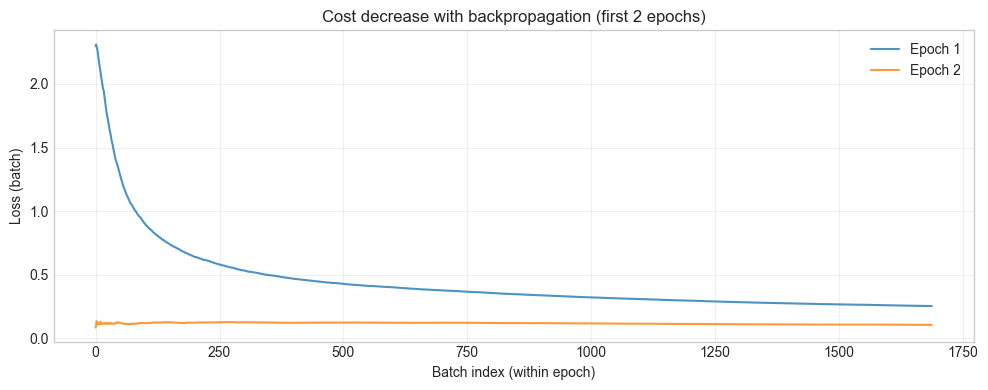

In [9]:
# Batch-level loss (cost decrease with backpropagation)
if batch_losses:
    df_batch = pd.DataFrame(batch_losses, columns=["epoch", "batch", "loss"])
    fig, ax = plt.subplots(figsize=(10, 4))
    for ep in sorted(df_batch["epoch"].unique()):
        sub = df_batch[df_batch["epoch"] == ep]
        ax.plot(sub["batch"], sub["loss"], alpha=0.8, label=f"Epoch {ep + 1}")
    ax.set_xlabel("Batch index (within epoch)")
    ax.set_ylabel("Loss (batch)")
    ax.set_title("Cost decrease with backpropagation (first 2 epochs)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No batch-level losses recorded. Re-run training with BatchLossLogger callback.")

---
## 4. Test set evaluation and metrics

Final performance on the held-out test set: loss, accuracy, and per-class precision, recall, and F1-score.

In [10]:
# Evaluate on test set (use one-hot labels for loss)
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=1)
y_pred_proba = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

# Summary
print("=" * 50)
print("Test set results")
print("=" * 50)
print(f"  Test loss:     {test_loss:.4f}")
print(f"  Test accuracy: {test_acc:.4f}")
print()

# Per-class and aggregate metrics
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, average=None, labels=range(10)
)
macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average="macro"
)
weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average="weighted"
)

# Table: per-class metrics
metrics_df = pd.DataFrame({
    "Class": range(10),
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "Support": support.astype(int),
})
total_support = int(support.sum())
metrics_df.loc["Macro avg", :] = ["—", f"{macro_p:.4f}", f"{macro_r:.4f}", f"{macro_f1:.4f}", total_support]
metrics_df.loc["Weighted avg", :] = ["—", f"{weighted_p:.4f}", f"{weighted_r:.4f}", f"{weighted_f1:.4f}", total_support]
print("Per-class and aggregate metrics:")
display(metrics_df)

# Scikit-learn classification report (text)
print("\nClassification report (sklearn):")
print(classification_report(y_test, y_pred, target_names=[str(i) for i in range(10)]))


  1/313 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 1.0000 - loss: 1.7946e-04

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 473us/step - accuracy: 0.9723 - loss: 0.1310
Test set results
  Test loss:     0.1310
  Test accuracy: 0.9723

Per-class and aggregate metrics:


/var/folders/ky/0zmfxgwn34g4_7py08z20p3r0000gn/T/ipykernel_49957/3167321661.py:34: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '—' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  metrics_df.loc["Macro avg", :] = ["—", f"{macro_p:.4f}", f"{macro_r:.4f}", f"{macro_f1:.4f}", total_support]
/var/folders/ky/0zmfxgwn34g4_7py08z20p3r0000gn/T/ipykernel_49957/3167321661.py:34: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.9725' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  metrics_df.loc["Macro avg", :] = ["—", f"{macro_p:.4f}", f"{macro_r:.4f}", f"{macro_f1:.4f}", total_support]
/var/folders/ky/0zmfxgwn34g4_7py08z20p3r0000gn/T/ipykernel_49957/3167321661.py:34: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise 

,Class,Precision,Recall,F1-score,Support
0,0.0,0.986639,0.979592,0.983103,980.0
1,1.0,0.992035,0.987665,0.989845,1135.0
2,2.0,0.979,0.948643,0.963583,1032.0
3,3.0,0.924004,0.987129,0.954524,1010.0
4,4.0,0.986472,0.965377,0.975811,982.0
5,5.0,0.970982,0.975336,0.973154,892.0
6,6.0,0.979058,0.975992,0.977522,958.0
7,7.0,0.979392,0.970817,0.975085,1028.0
8,8.0,0.967975,0.962012,0.964985,974.0
9,9.0,0.959764,0.969277,0.964497,1009.0



Classification report (sklearn):
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.95      0.96      1032
           3       0.92      0.99      0.95      1010
           4       0.99      0.97      0.98       982
           5       0.97      0.98      0.97       892
           6       0.98      0.98      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.97      0.96      0.96       974
           9       0.96      0.97      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



**Test metrics:** Test accuracy and test loss summarize overall performance on held-out data. **Precision** (for a digit) is “when the model predicts this digit, how often is it correct?” **Recall** is “of all true instances of this digit, how many did the model find?” **F1-score** is the harmonic mean of precision and recall. **Macro** averages treat every class equally; **weighted** averages weight by support (number of test samples per class). Digits that look similar (e.g. 4 vs 9, 3 vs 5, 7 vs 1) often have slightly lower precision or recall; consistently high F1 across classes means the model generalizes well to all digits.

### 4.1 Confusion matrix

Rows: true label. Columns: predicted label. Diagonal = correct predictions.

**Confusion matrix:** Each row is a true digit, each column is the predicted digit. The **diagonal** counts correct predictions; off-diagonal cells are errors. For example, the cell at row 4, column 9 is “true 4 predicted as 9.” Strong diagonal and small off-diagonal values indicate good classification. If certain pairs (e.g. 4↔9, 3↔5, 7↔1) have higher counts, those are the confusions to focus on if you want to improve the model (e.g. with more data, augmentation, or a different architecture).

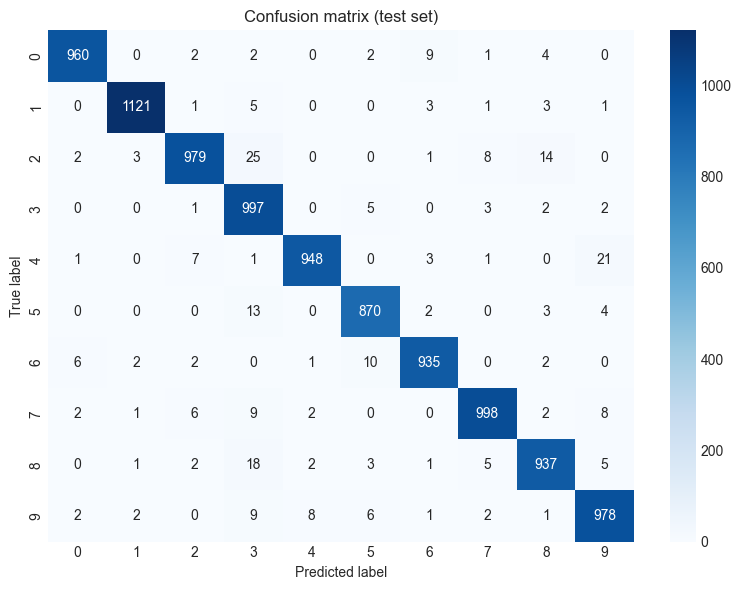

In [11]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=range(10), yticklabels=range(10))
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion matrix (test set)")
plt.tight_layout()
plt.show()

**Summary:** Final train loss is much lower than validation/test loss because the model has seen the training data many times. Validation and test loss are close, which suggests the 10% validation split is representative and we are not overfitting badly. Test accuracy and macro/weighted F1 in the high 90s are typical for a small MLP on MNIST; the remaining errors are mostly ambiguous or noisy digits. For production or reporting, cite test accuracy and macro F1, and use the confusion matrix to describe which digits are hardest to distinguish.

---
## 5. Summary

Key metrics

In [12]:
# Key metrics summary (for reporting)
summary = pd.DataFrame({
    "Metric": [
        "Final train loss",
        "Final validation loss",
        "Test loss",
        "Test accuracy",
        "Macro F1 (test)",
        "Weighted F1 (test)",
    ],
    "Value": [
        f"{history.history['loss'][-1]:.4f}",
        f"{history.history['val_loss'][-1]:.4f}",
        f"{test_loss:.4f}",
        f"{test_acc:.4f}",
        f"{macro_f1:.4f}",
        f"{weighted_f1:.4f}",
    ],
})
display(summary)

,Metric,Value
0,Final train loss,0.0202
1,Final validation loss,0.1277
2,Test loss,0.1310
3,Test accuracy,0.9723
4,Macro F1 (test),0.9722
5,Weighted F1 (test),0.9724
